**Decomposição matricial de vídeos**
====================


**Curso:** Doutorado em Matemática Aplicada e Computacional

**Instituição:** Universidade Estadual Paulista "Júlio de Mesquita Filho" (UNESP)

**Docente:** Dr. Cássio Machiaveli Oishi

**Estudante:** Nelson Roldan Condori Colquehuanca

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import glob
import os
from numpy.linalg import svd, norm

**CONFIGURAÇÃO E CARREGAMENTO DE DADOS**

In [20]:
def carregar_imagens_para_matriz(caminho_pasta, num_frames=10, resize_shape=(60, 80)):
    # Busca imagens jpg ou png e as ordena numericamente
    arquivos = sorted(glob.glob(os.path.join(caminho_pasta, "*.*")))

    # Filtra apenas extensões de imagem
    arquivos = [f for f in arquivos if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if len(arquivos) < num_frames:
        print(f"Aviso: Apenas {len(arquivos)} imagens foram encontradas.")
        num_frames = len(arquivos)

    frames = []
    print(f"Carregando {num_frames} imagens de {caminho_pasta}...")

    for i in range(num_frames):
        img = cv2.imread(arquivos[i])
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        # cv2 usa (largura, altura)
        resized = cv2.resize(gray, (resize_shape[1], resize_shape[0]))
        frames.append(resized.flatten()) # Achatamos para vetor coluna

    M = np.array(frames).T # Transpor para que cada coluna seja um frame (tempo)
    return M, resize_shape

**IMPLEMENTAÇÃO RPCA (ALGORITMO)**

In [19]:
def rpca_simples(M, lam=None, max_iter=100, tol=1e-7):
    # Inicialização
    n1, n2 = M.shape
    L = np.zeros_like(M)
    S = np.zeros_like(M)
    Y = np.zeros_like(M)

    if lam is None:
        lam = 1.0 / np.sqrt(max(n1, n2)) # Lambda heurístico clássico

    mu = 1.25 / norm(M, 2) # Taxa de aprendizado

    print(f"Executando RPCA com Lambda: {lam:.5f}")

    for k in range(max_iter):
        # Atualizar L (Fundo) usando SVD (Singular Value Thresholding)
        U, s, Vt = svd(M - S + (1/mu)*Y, full_matrices=False)
        s_thresh = np.maximum(s - (1/mu), 0)
        L_new = np.dot(U * s_thresh, Vt)

        # Atualizar S (Objetos) usando Soft Thresholding
        residuo = M - L_new + (1/mu)*Y
        S_new = np.sign(residuo) * np.maximum(np.abs(residuo) - (lam/mu), 0)

        # Atualizar Multiplicador de Lagrange (Y)
        Z = M - L_new - S_new
        Y = Y + mu * Z

        # Erro e Convergência
        error = norm(Z, 'fro') / norm(M, 'fro')
        L, S = L_new, S_new

        if error < tol:
            break

    return L, S

**EXECUÇÃO PRINCIPAL**

Executando RPCA com Lambda: 0.01443


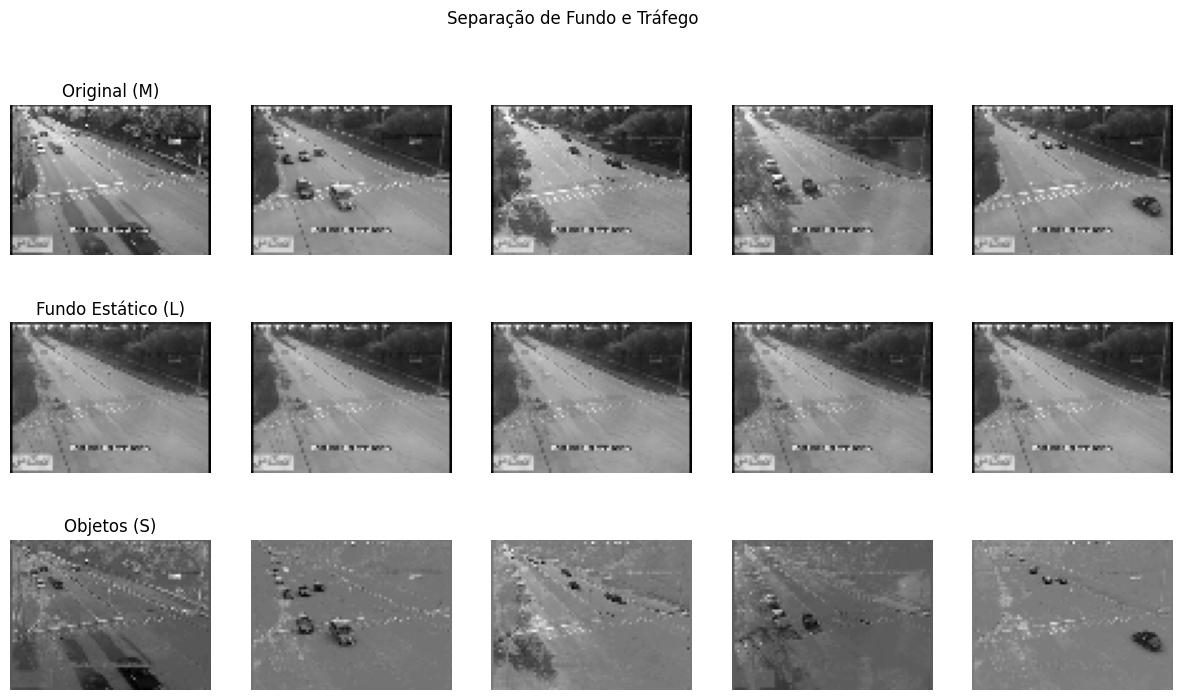

Erro de Reconstrução: 0.00423386


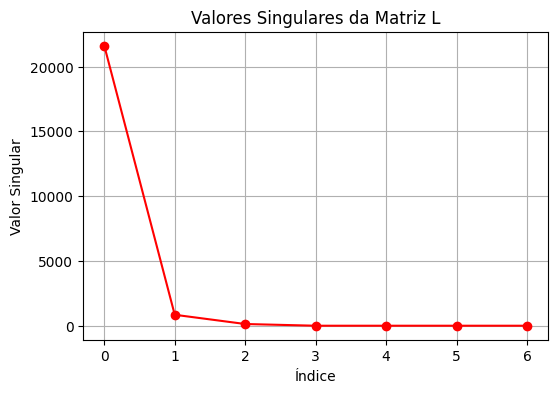

In [21]:
# IMAGENS DO VIDEO
pasta_imagens = "/content/drive/MyDrive/Colab Notebooks/Álgebra Linear CD 2025/Datos/trafic_data"
# A. Executar RPCA Normal
L, S = rpca_simples(M_raw)

# B. Visualização
fig, axes = plt.subplots(3, 5, figsize=(15, 8))
frames_to_show = 5
for i in range(frames_to_show):
    # Original
    axes[0, i].imshow(M_raw[:, i].reshape(shape_img), cmap='gray')
    axes[0, i].axis('off')
    if i==0: axes[0, i].set_title("Original (M)")

    # Fundo (L)
    axes[1, i].imshow(L[:, i].reshape(shape_img), cmap='gray')
    axes[1, i].axis('off')
    if i==0: axes[1, i].set_title("Fundo Estático (L)")

    # Movimento (S)
    axes[2, i].imshow(S[:, i].reshape(shape_img), cmap='gray')
    axes[2, i].axis('off')
    if i==0: axes[2, i].set_title("Objetos (S)")

plt.suptitle("Separação de Fundo e Tráfego")
plt.show()

# C. Erro de Reconstrução
error_rec = norm(M_raw - (L + S), 'fro') / norm(M_raw, 'fro')
print(f"Erro de Reconstrução: {error_rec:.8f}")

# D. Valores Singulares de L (Verificação Low-Rank)
_, s_vals, _ = svd(L, full_matrices=False)
plt.figure(figsize=(6,4))
plt.plot(s_vals, 'o-r')
plt.title("Valores Singulares da Matriz L")
plt.xlabel("Índice"); plt.ylabel("Valor Singular")
plt.grid(True)
plt.show()

Observación: La caída rápida indica que poca información (pocos modos) define el fondo estático.